In [4]:
import numpy as np
from matplotlib import pyplot as plt
import sys
sys.path.append('../simplify')
sys.path.append('../')
import importlib, utils, mass_function
importlib.reload(utils)
importlib.reload(mass_function)

utils.my_mpl()

import importlib, lf_plotter, lf_model, lf_optimizer
importlib.reload(lf_optimizer)
importlib.reload(lf_plotter)
importlib.reload(lf_model)
from lf_plotter import LFPlotter
from lf_model import FiducialCLF, FuzzyCLF
from lf_optimizer import LFOptimizer, run_optimize

In [5]:
fdm_dirs = ['../simplify/lf/fdm_21/', '../simplify/lf/fdm_2122/']
dir2122 = '../simplify/lf/2122/'

In [38]:
run_optimize([fdm_dirs[1]], ModelClass=FuzzyCLF, x0=lf_optimizer.BEST_X0_FDM, prior=lf_optimizer.FDM_PRIOR, maxiter=10000, maxfev=10000)

one
../simplify/lf/fdm_2122/
two
three None
four


/home/jsipple/.conda/envs/jsipple/lib/python3.7/site-packages/scipy/optimize/_minimize.py:516: RuntimeWarning: Method Nelder-Mead cannot handle constraints nor bounds.
  RuntimeWarning)
../simplify/utils.py:128: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


five  final_simplex: (array([[  1.69567154,   1.54660777,   1.12093781, -23.32887259,
         11.92539099,  10.37706463],
       [  1.69567154,   1.54660777,   1.12093781, -23.32887259,
         11.92539099,  10.37705826],
       [  1.69567154,   1.54660777,   1.12093781, -23.32887259,
         11.92539099,  10.37711446],
       [  1.69567154,   1.54660777,   1.12093781, -23.32887259,
         11.92539099,  10.37708229],
       [  1.69567154,   1.54660777,   1.12093781, -23.32887259,
         11.92539099,  10.37715152],
       [  1.69567154,   1.54660777,   1.12093781, -23.32887259,
         11.92539099,  10.37712699],
       [  1.69567154,   1.54660777,   1.12093781, -23.32887259,
         11.92539099,  10.37705158]]), array([177.25019379, 177.25019379, 177.25019379, 177.25019379,
       177.25019379, 177.25019379, 177.25019379]))
           fun: 177.2501937916209
       message: 'Optimization terminated successfully.'
          nfev: 1136
           nit: 694
        status: 0
      

In [34]:
run_optimize(fdm_dirs, ModelClass=FuzzyCLF, x0=lf_optimizer.BEST_X0_FDM_BIGP, prior=lf_optimizer.FDM_PRIOR, minimize_method='SLSQP')

one
../simplify/lf/fdm_21/
two
three None
four


../simplify/utils.py:128: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


five      fun: 75.23345027542409
     jac: array([-0.00098419, -0.00032806,  0.00019455, -0.00125217, -0.00423336,
       -0.00203991])
 message: 'Optimization terminated successfully.'
    nfev: 220
     nit: 27
    njev: 26
  status: 0
 success: True
       x: array([  1.83469474,   1.33409717,   0.87650531, -22.66938007,
        11.65944889,   3.        ])
     fun: 75.23345027542409
     jac: array([-0.00098419, -0.00032806,  0.00019455, -0.00125217, -0.00423336,
       -0.00203991])
 message: 'Optimization terminated successfully.'
    nfev: 220
     nit: 27
    njev: 26
  status: 0
 success: True
       x: array([  1.83469474,   1.33409717,   0.87650531, -22.66938007,
        11.65944889,   3.        ])
../simplify/lf/fdm_2122/
two
three None
four
five      fun: 177.261413539667
     jac: array([ 0.01766014, -0.00320435, -0.00053596, -0.00251961,  0.00386047,
       -0.03790092])
 message: 'Optimization terminated successfully.'
    nfev: 246
     nit: 29
    njev: 28
  status: 0

In [8]:
np.array(lf_optimizer.FDM_PRIOR).shape
np.array(lf_optimizer.B15_X0_FDM).shape

(6,)

In [56]:
lf_optimizer.run_mcmc([fdm_dirs[1]], FuzzyCLF, x0=lf_optimizer.BEST_X0_FDM_BIGP, prior=lf_optimizer.FDM_PRIOR, n_steps=10000, reset=False)

START
../simplify/lf/fdm_2122/


100%|██████████| 5000/5000 [1:30:26<00:00,  1.09s/it]


['B21+22 Fit', 'FDM 21', 'FDM 21+22'] [0.2 0.2 0.2] [  1.69567366   1.54668554   1.1209801  -23.3288954   11.92540231] 0
['B21+22 Fit', 'FDM 21', 'FDM 21+22'] [0.2 0.2 0.2] [  1.83469119   1.3341009    0.87655389 -22.66934933  11.65944978
   3.        ] 1
['B21+22 Fit', 'FDM 21', 'FDM 21+22'] [0.2 0.2 0.2] [  1.69563469   1.54663834   1.12092463 -23.3289904   11.92543799
   3.        ] 2
['$p$', '$q$', '$r$', '$L_0$ [mag]', '$\\log_{10}(M_1/$M$_\\odot)$', '$\\log_{10}(m_{FDM}/10^{-22}$eV$)$']


../simplify/utils.py:128: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


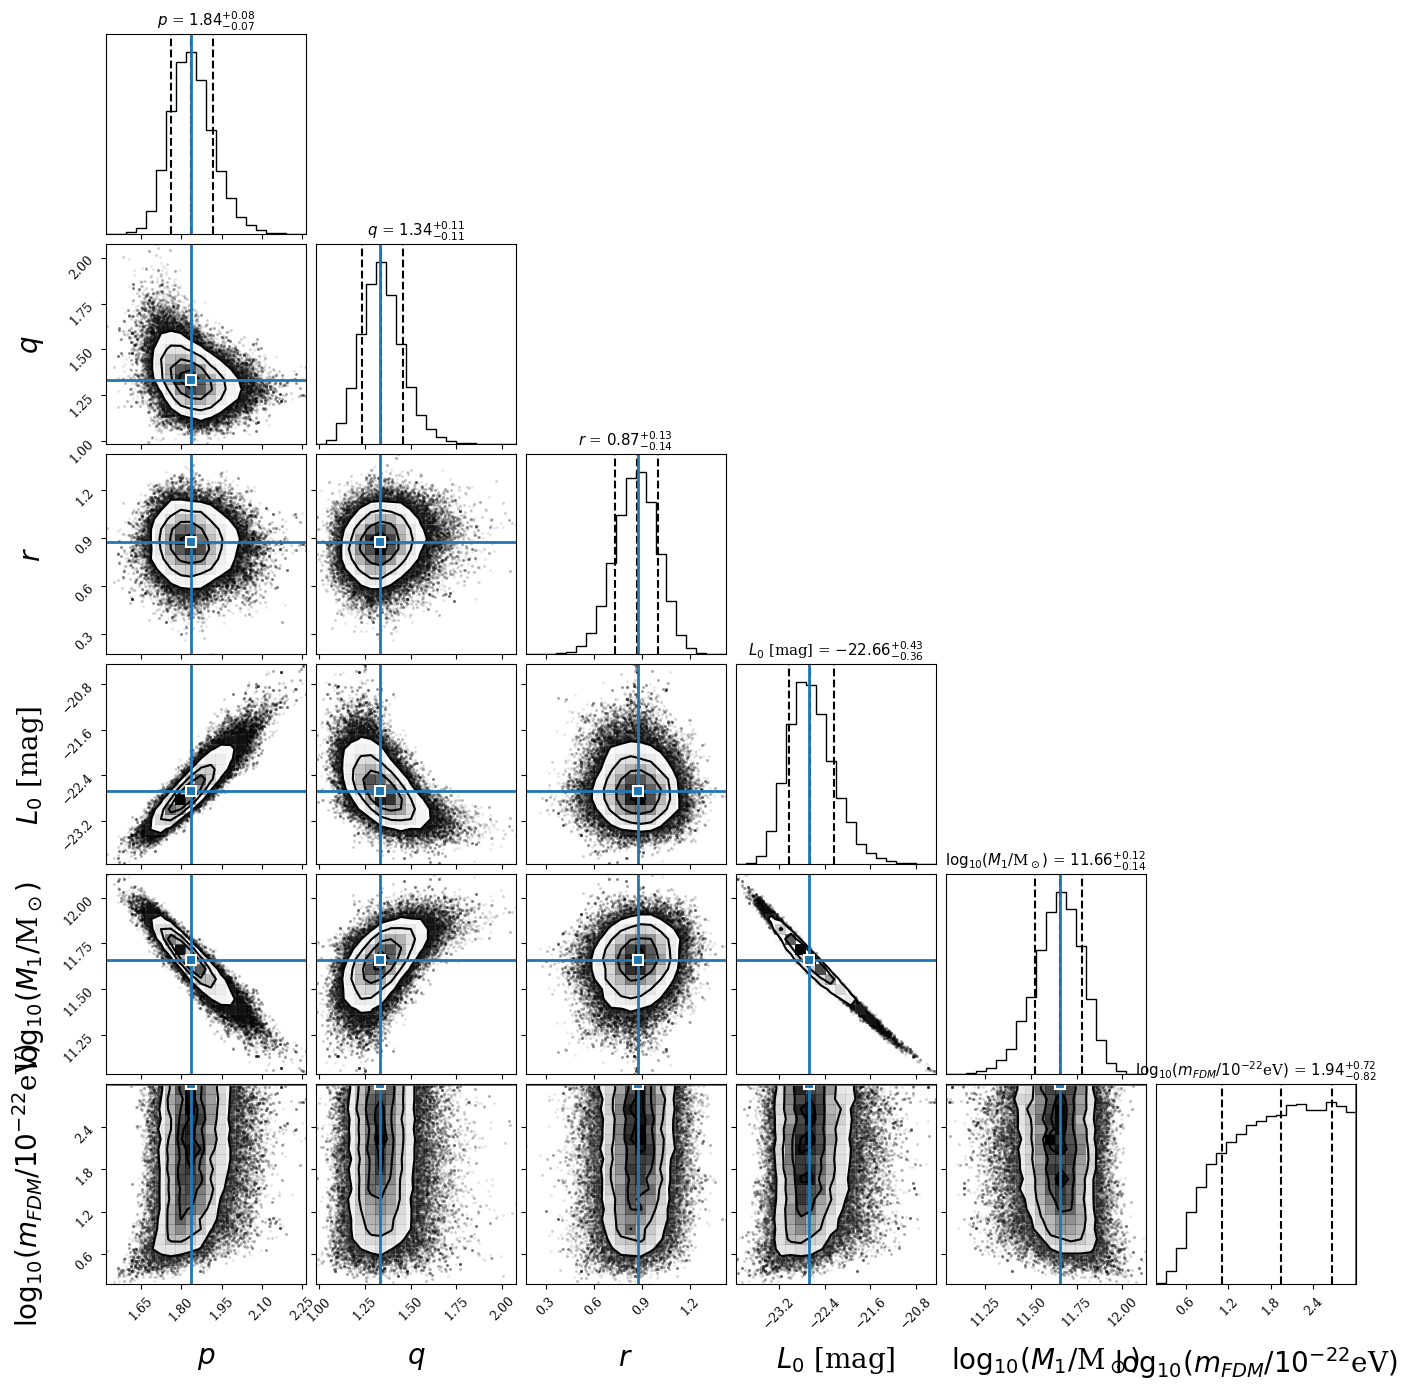

In [31]:
plotter_fdm = LFPlotter([dir2122, fdm_dirs[0], fdm_dirs[1]], names=['B21+22 Fit', r'FDM 21', r'FDM 21+22'], ModelClass=[FiducialCLF, FuzzyCLF, FuzzyCLF])
plotter_fdm.plot_corner(which_model=1, burn_in=500)

['B21+22 Fit', 'FDM 21', 'FDM 21+22'] [0.2 0.2 0.2] [  1.69567366   1.54668554   1.1209801  -23.3288954   11.92540231] 0
['B21+22 Fit', 'FDM 21', 'FDM 21+22'] [0.2 0.2 0.2] [  1.83456816   1.3340924    0.87639964 -22.66985467  11.65959854
   2.60437692] 1
['B21+22 Fit', 'FDM 21', 'FDM 21+22'] [0.2 0.2 0.2] [  1.69567154   1.54660777   1.12093781 -23.32887259  11.92539099
  10.37706463] 2


../simplify/utils.py:129: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


['$p$', '$q$', '$r$', '$L_0$ [mag]', '$\\log_{10}(M_1/$M$_\\odot)$', '$\\log_{10}(m_{FDM}/10^{-22}$eV$)$']


autocorrelation times: [425.21978081 125.17588008 129.886738   371.19929954 340.91222788
 255.29878399]


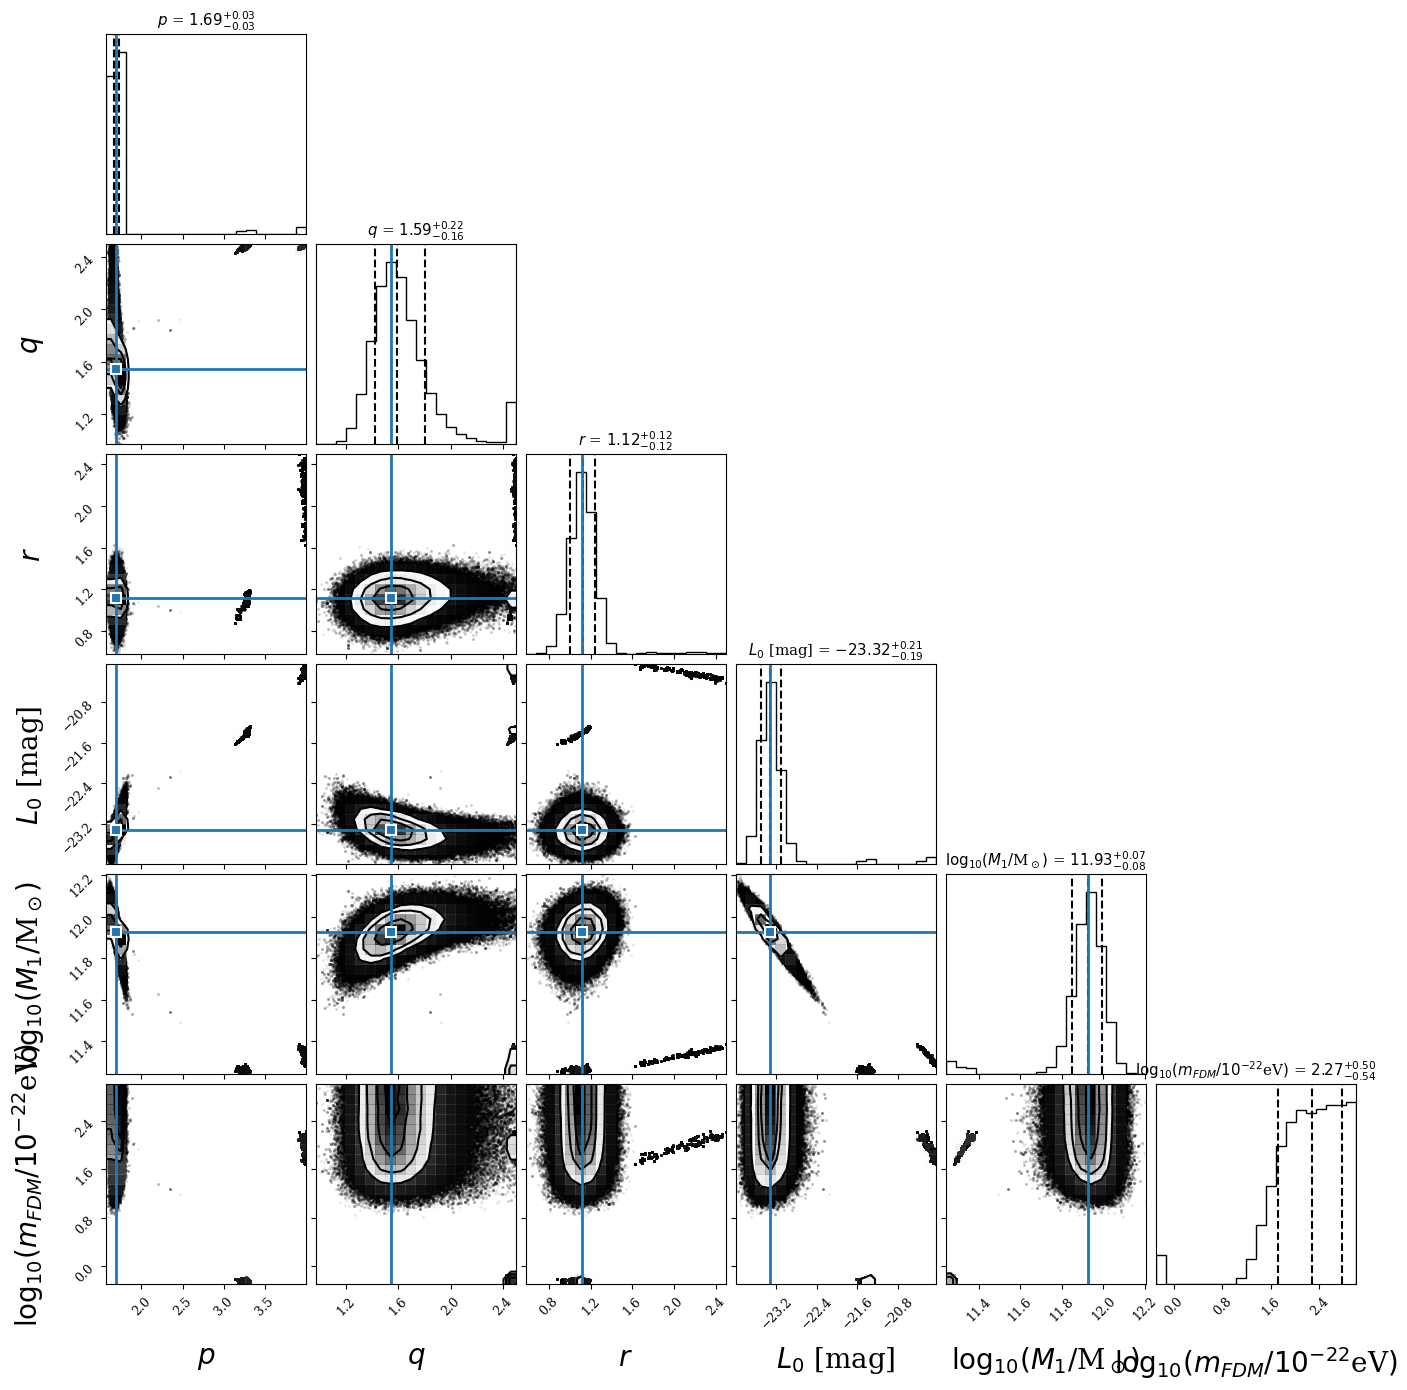

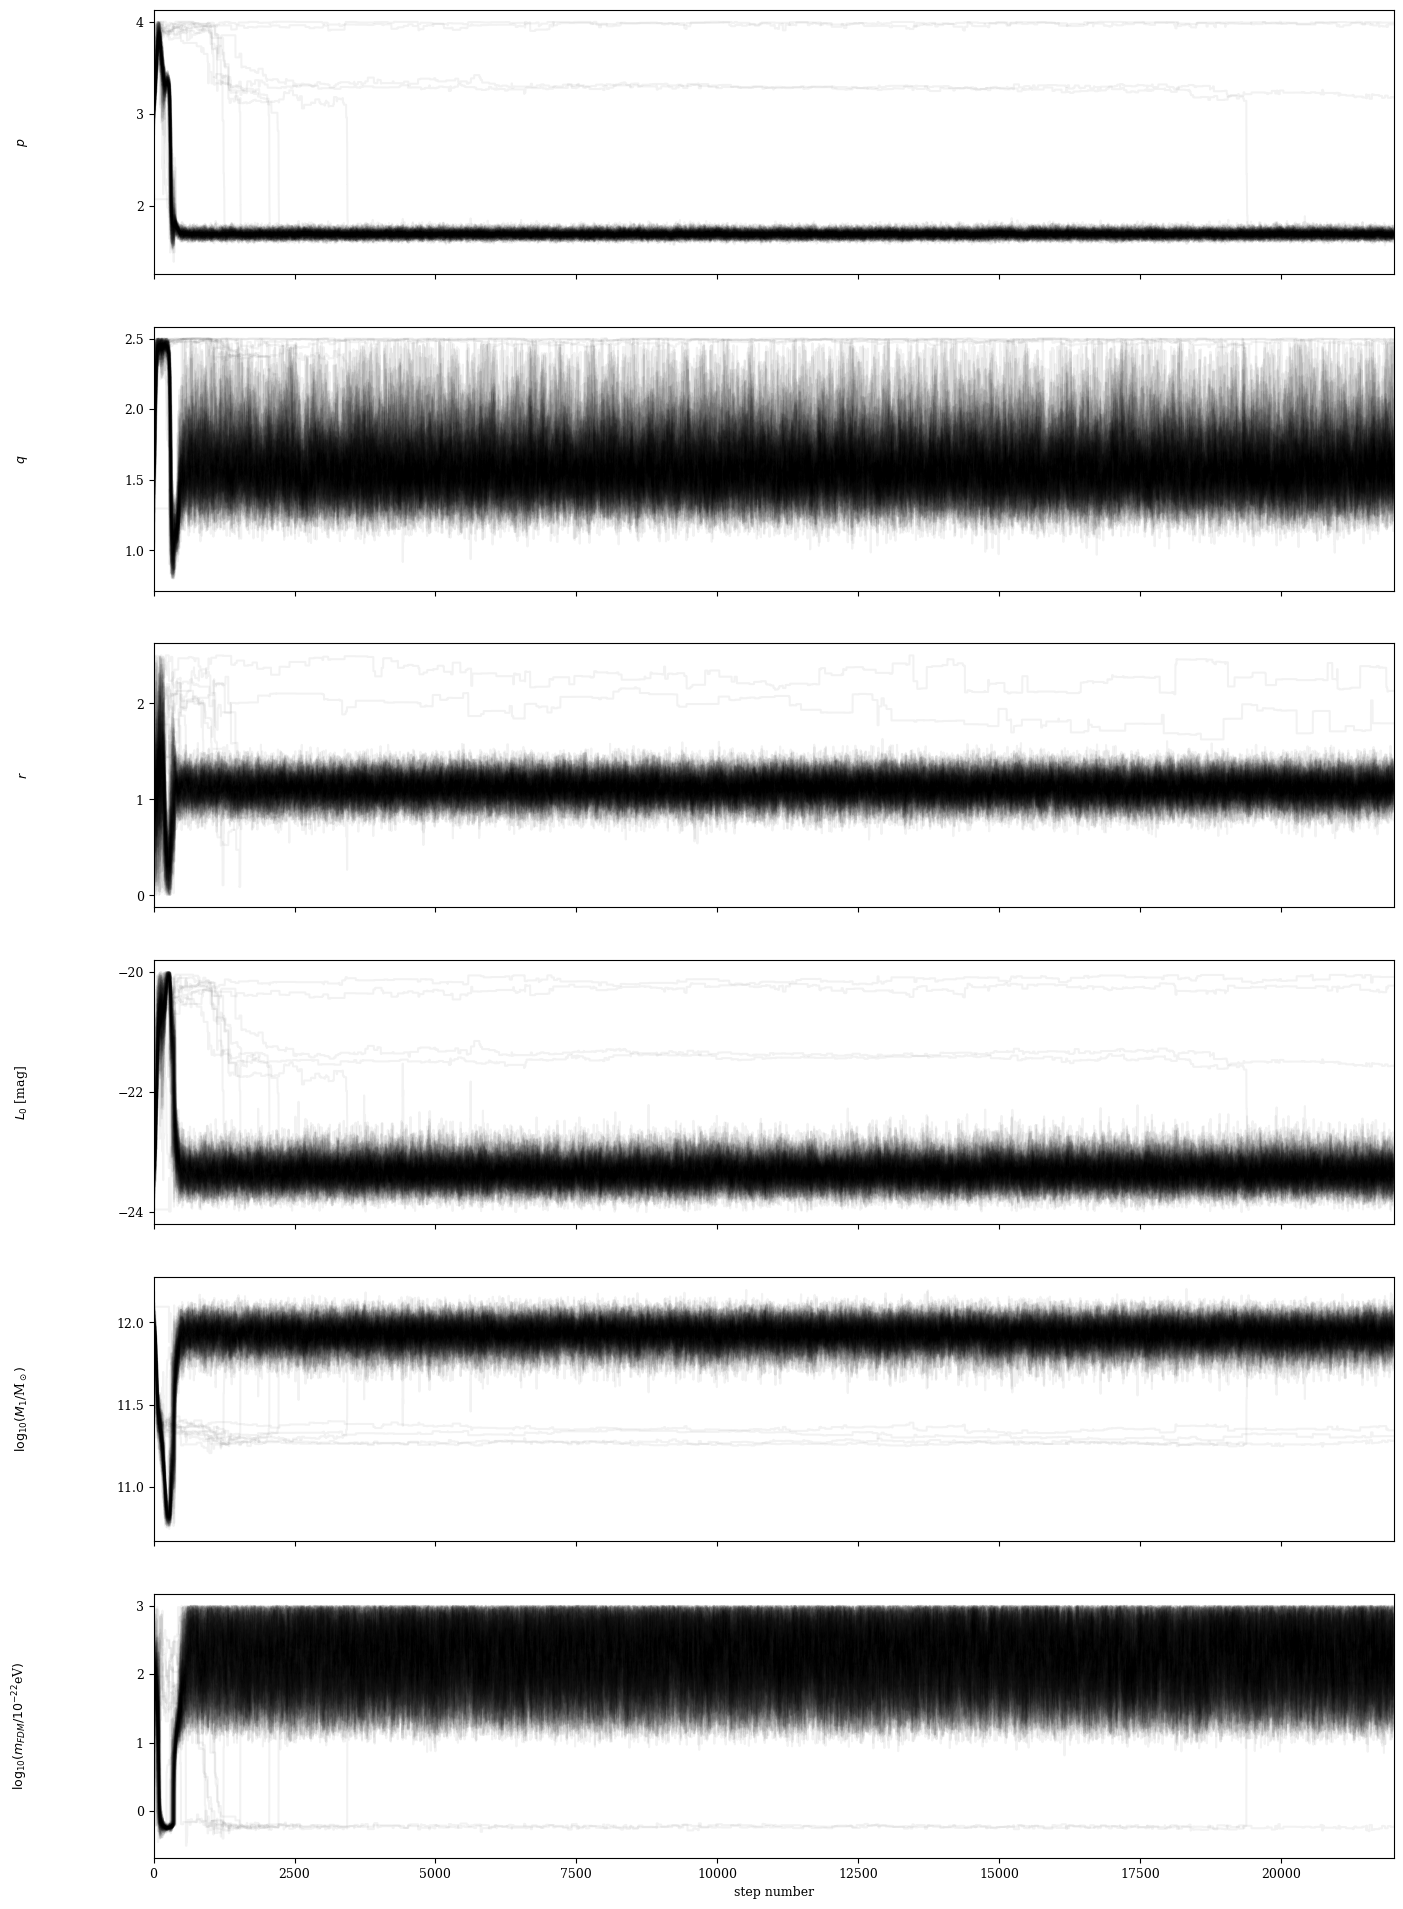

In [3]:
plotter_fdm = LFPlotter([dir2122, fdm_dirs[0], fdm_dirs[1]], names=['B21+22 Fit', r'FDM 21', r'FDM 21+22'], ModelClass=[FiducialCLF, FuzzyCLF, FuzzyCLF])
plotter_fdm.plot_corner(which_model=2, burn_in=10000, plot_walkers=True)

In [8]:
plotter_fdm2122 = LFPlotter([fdm_dirs[1]], names=[r'FDM 21+22'], ModelClass=FuzzyCLF)
plotter_fdm2122.plot_fits(use_bands=True)

['FDM 21+22'] [0.2] [  1.69567154   1.54660777   1.12093781 -23.32887259  11.92539099
  10.37706463] 0


../simplify/utils.py:129: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)
../simplify/utils.py:129: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


../simplify/utils.py:129: RuntimeWarning: divide by zero encountered in log
  logy = np.log(y)


KeyboardInterrupt: 

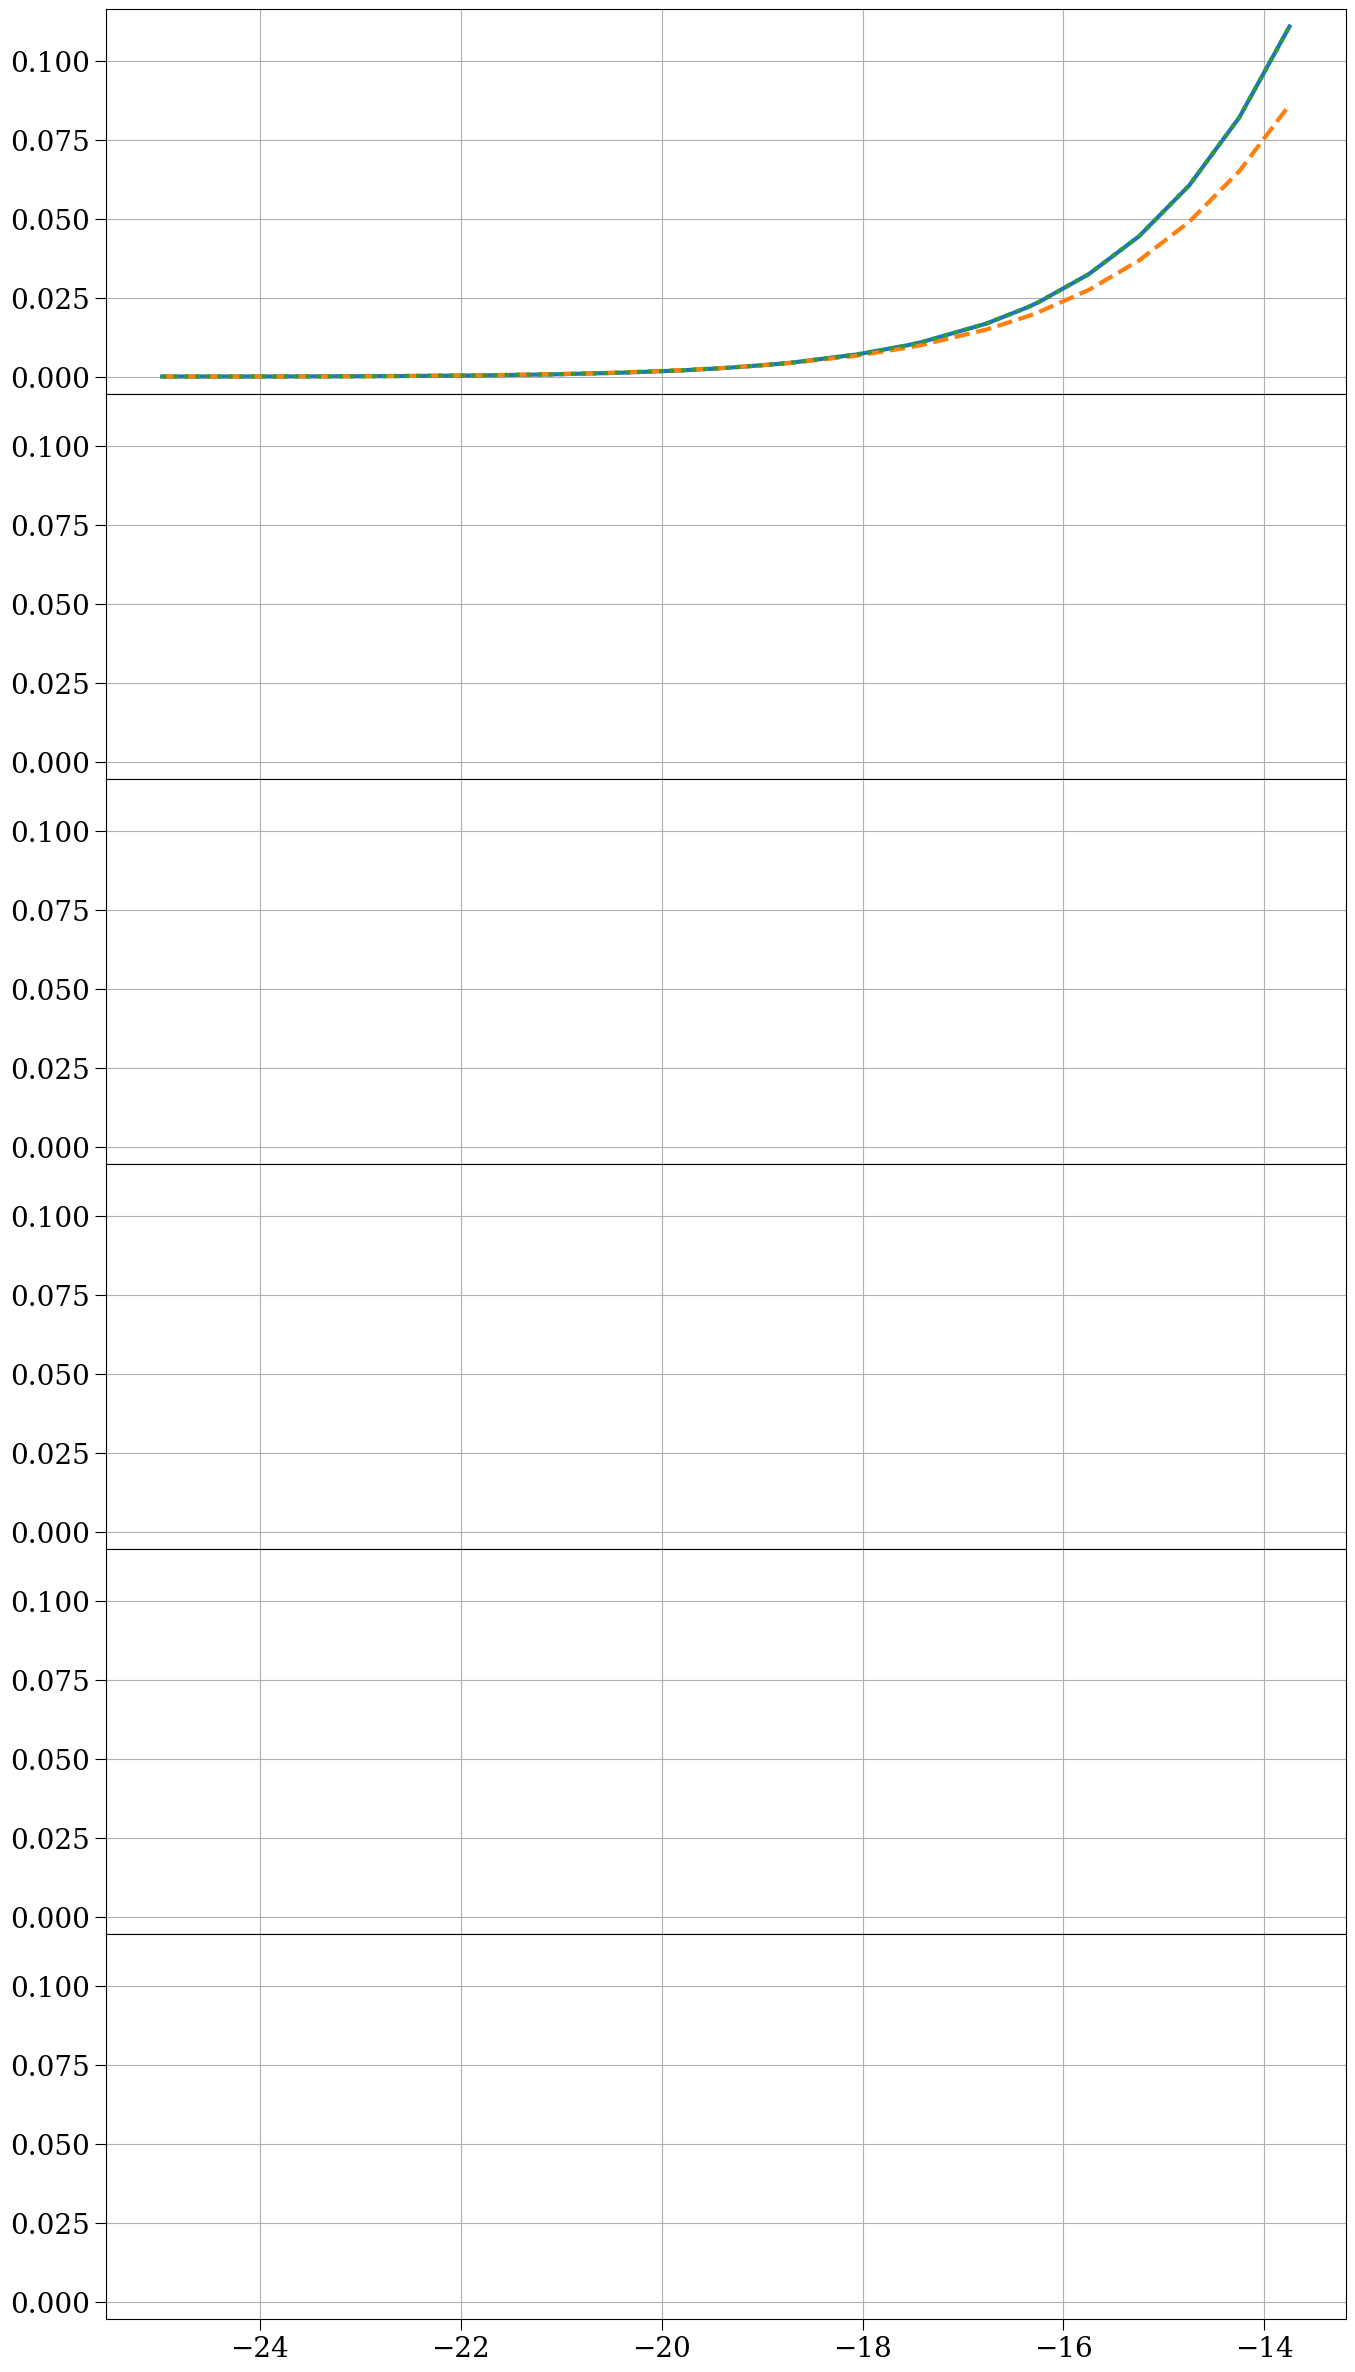

In [6]:
plotter_fdm.plot_fits(use_bands=True)

In [61]:
reader = plotter_fdm.mcmc_readers[2]
samples = reader.get_chain()
samples.shape

(12000, 96, 6)

In [62]:
for i in range(96):
    x = samples[-1:,i, -1]
    if x < 1:
        print(i, x)

52 [-0.24857414]
67 [-0.22746701]


In [63]:
print(samples[-1:,52, :])
print(samples[-1:,67, :])

[[  3.29580724   2.48990035   1.1429127  -21.35828856  11.27075696
   -0.24857414]]
[[  3.28816321   2.49595744   1.07976084 -21.42670449  11.25896094
   -0.22746701]]


In [69]:
for k in range(96):
    print('THREAD#', k, ":")
    for i in range(10):
        model = FuzzyCLF(meas_fn='../simplify/lf/fdm_2122/meas.npz', params=samples[-i:,k, :][0])
        print(np.round(model.chi_sq_of_model()/model.dof, 2), end=' ')
    print()

THREAD# 0 :
48.25 

../simplify/utils.py:129: RuntimeWarning: divide by zero encountered in log
  lin_interpolator = interp1d(


1.76 1.76 1.74 1.74 1.74 1.74 1.74 1.75 1.71 
THREAD# 1 :
38.29 1.75 1.75 1.75 1.75 1.75 1.75 1.75 1.75 1.72 
THREAD# 2 :
38.42 1.73 1.73 1.73 1.73 1.73 1.74 1.74 1.72 1.72 
THREAD# 3 :
39.12 1.71 1.7 1.7 1.7 1.7 1.7 1.7 1.7 1.7 
THREAD# 4 :
41.48 1.74 1.74 1.74 1.74 1.74 1.74 1.74 1.74 1.73 
THREAD# 5 :
38.87 1.78 1.77 1.76 1.8 1.86 1.79 1.79 1.8 1.81 
THREAD# 6 :
38.14 1.73 1.73 1.75 1.75 1.75 1.75 1.75 1.76 1.76 
THREAD# 7 :
42.78 1.76 1.76 1.76 1.76 1.76 1.76 1.79 1.79 1.78 
THREAD# 8 :
38.55 1.74 1.74 1.74 1.74 1.74 1.74 1.74 1.74 1.74 
THREAD# 9 :
45.57 34.5 34.5 34.5 34.5 34.5 34.5 34.5 34.5 34.5 
THREAD# 10 :
41.54 1.72 1.72 1.72 1.72 1.72 1.74 1.74 1.74 1.71 
THREAD# 11 :
38.49 1.75 1.75 1.75 1.75 1.75 1.75 1.72 1.72 1.72 
THREAD# 12 :
58.79 1.76 1.76 1.84 1.84 1.84 1.84 1.74 1.73 1.74 
THREAD# 13 :
38.75 1.74 1.76 1.76 1.76 1.75 1.75 1.79 1.79 1.79 
THREAD# 14 :
48.26 1.75 1.71 1.71 1.71 1.71 1.71 1.72 1.72 1.7 
THREAD# 15 :
39.75 1.72 1.72 1.72 1.72 1.72 1.72 1.75 1.75 1.71 